Astro 19 Group Project, Justin Howard


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import norm as nm
%matplotlib inline

In [2]:
data = np.loadtxt(r"Asto19\group_project_dataset.txt", skiprows=23)
times = data[:, 0]
velocities = data[:, 1]
error = data[:, 2]
times = np.float64(times - np.min(times))

In [3]:
np.random.seed(333)
x = times
a = (np.max(velocities) - np.min(velocities))/2
vmaxt1 = 2450202.68868
vmaxt2 = 2454598.70674
vmaxt3 = 2450437.92852
vmaxt4 = 2450503.76303
b = np.min(times)
c = ((vmaxt2)-(vmaxt1))
d = np.mean(velocities)
noise = 0.5
sigma = np.std(velocities)
points = num_points = data[:,0].shape[0]
xfit = np.linspace(np.min(times),np.max(times),len(times))
y = np.float64(a * np.sin(2.0 * np.pi * (x-b)/c) + d)

In [4]:
def ofunc(x,a,b,c,d):
    return a*np.sin(2.0*np.pi*(x-b)/c)+d

guess_params = [a, b, c, d]

param1, param_cov = optimize.curve_fit(
    ofunc,
    x,
    velocities,
    p0=guess_params,
    sigma=error
)

afit, bfit, cfit, dfit = param1
print(afit, bfit, cfit, dfit)
y2 = ofunc(xfit, afit, bfit, cfit, dfit)

47.92541794377276 -660.1795650852982 4790.273458785798 -1.4842561466543711


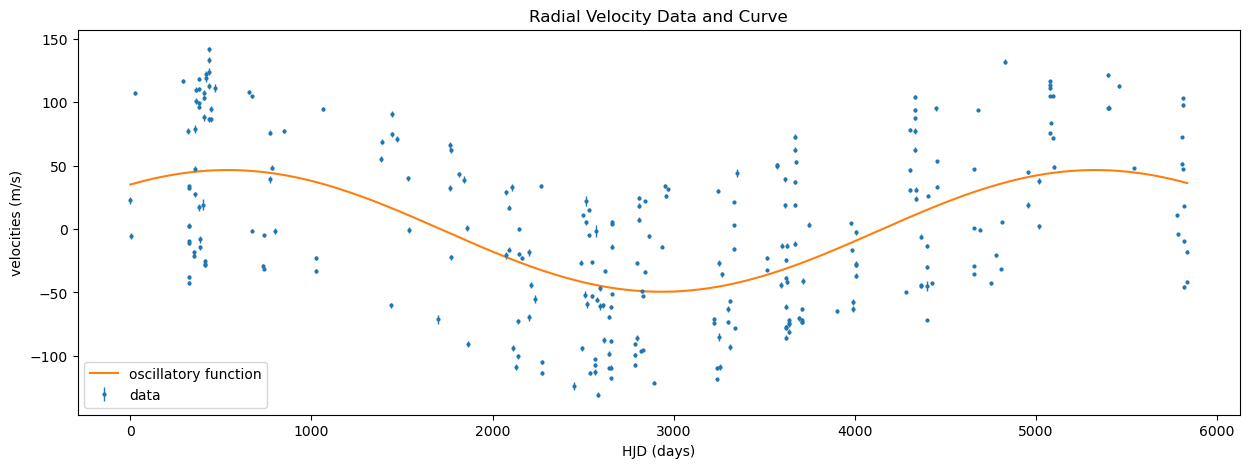

In [5]:
plt.figure(1, figsize=(15,5))
plt.errorbar(times,velocities, yerr = error, fmt='o', markersize=2, elinewidth=1, label="data")
plt.plot(xfit,y2, label="oscillatory function")
plt.xlabel("HJD (days)")
plt.ylabel("velocities (m/s)")
plt.title("Radial Velocity Data and Curve")
plt.legend(loc=0)

In [6]:
residuals = velocities - y2
width = 2
histmin = np.floor(np.min(residuals))
histmax = np.ceil(np.max(residuals))
bins = np.arange(histmin, histmax, width)

In [7]:
sd = np.std(velocities)
print(sd)

66.71519312102595


g = len(residuals)
units = np.linspace(np.min(residuals),np.max(residuals), g)
histo, bins2 = np.histogram(residuals,bins)
bins2 += 1
bins2 = np.delete(bins2, -1)
print(histo)

In [8]:
g = len(residuals)
units = np.linspace(np.min(residuals),np.max(residuals), g)
rm = np.mean(residuals)
sdr = np.std(residuals)

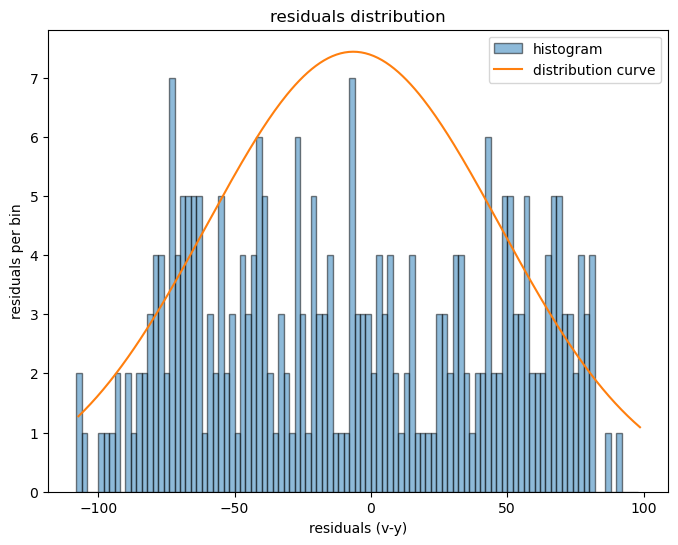

In [9]:
plt.figure(2,figsize=(8,6))
plt.hist(residuals, bins, alpha = 0.5, edgecolor='black', label = "histogram")
xmin, xmax = plt.xlim()
#units = np.linspace(xmin, xmax, p2)
histo = nm.pdf(units,rm,sdr)
plt.plot(units, histo*(10**3),label="distribution curve")
plt.xlabel("residuals (v-y)")
plt.ylabel("residuals per bin")
plt.title("residuals distribution")
plt.legend(loc=0)

In [10]:
plt.show()
#plt.savefig("test1.png", bbox_inches="tight", facecolor="white", dpi=300)

In [11]:
starmass = 0.95
planetmass1 = (afit/28.4)*(cfit/365)**(1/3)*(starmass)**(2/3)
print(str(planetmass1) + " Jupiter's mass")
print(str(planetmass1) + "is a has a simular mass as 55 Cnc d which is 3.8 Jupiter's mass")

3.8466775812695664 Jupiter's mass
3.8466775812695664is a has a simular mass as 55 Cnc d which is 3.8 Jupiter's mass
